## Names dataset (Improved Model)

In [1]:
### Imports , Data, Tokenizer
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
import matplotlib.pyplot as plt
import itertools
import json
import os
import time

## Device 
device=torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device:{device}")

Device:cpu


In [2]:
### load names
names=open("/Users/mac/Desktop/Machine Learning/DL/DB/Names/names.txt").read().splitlines()

vocab=sorted(set("".join(names)+"."))
vocab_size=len(vocab)

stoi={ch: i for i, ch in enumerate(vocab)}
itos={i:ch for i, ch in enumerate(vocab)}

def encode(text):
    return [stoi[ch] for ch in text if ch in stoi]

def decode(ids):
    return "".join([itos[i] for i in ids])

print(f"Vocab size:{vocab_size}" )
print(f"Names:{len(names)}")

Vocab size:27
Names:32033


## Dataset class

In [3]:
class NamesDataset(Dataset):
    def __init__(self, names_list, block_size):
        self.block_size=block_size
        X, Y=[],[]
        for name in names_list:
            context=[0]*block_size
            for ch in name+ ".":
                ix=stoi[ch]
                X.append(context)
                Y.append(ix)
                context=context[1:]+[ix]
                
                
        self.X=torch.tensor(X, dtype=torch.long)
        self.Y=torch.tensor(Y, dtype=torch.long)
        
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.Y[idx]
    

## BatchNorm

In [4]:
class BatchNorm1d(nn.Module):
    def __init__(self, dim, momentum=0.1):
        super().__init__()
        self.momentum=momentum
        self.eps=1e-6
        self.scale=nn.Parameter(torch.ones(dim))
        self.shift=nn.Parameter(torch.zeros(dim))
        self.register_buffer("running_mean", torch.zeros(dim))
        self.register_buffer("running_var",  torch.ones(dim))
        
    def forward(self, x):
        if self.training:
            xmean=x.mean(dim=0, keepdim=True)
            xvar=x.var(dim=0, keepdim=True)
            
            with torch.no_grad():
                self.running_mean=(1-self.momentum)*self.running_mean+self.momentum*xmean.squeeze(0)
                self.running_var=(1-self.momentum)*self.running_var+ self.momentum*xvar.squeeze(0)
                
        else:
            xmean=self.running_mean
            xvar=self.running_var
            
        x=(x-xmean)/(xvar+self.eps)**0.5
        return self.scale*x+self.shift


## Model

In [5]:
class NameGenerator(nn.Module):
    def __init__(self, vocab_size, n_embd, block_size, n_hidden, n_layers, dropout=0.2):
        super().__init__()
        self.block_size=block_size
        
        self.E=nn.Embedding(vocab_size, n_embd)
        self.input_proj=nn.Linear(block_size*n_embd, n_hidden, bias=False)
        self.input_bn=BatchNorm1d(n_hidden)
        self.drop=nn.Dropout(dropout)
        
        self.layers=nn.ModuleList([
            nn.Linear(n_hidden, n_hidden, bias=False) for _ in range(n_layers)
        ])
        
        self.bns=nn.ModuleList([
            BatchNorm1d(n_hidden) for _ in range(n_layers)
        ])
        
        self.out=nn.Linear(n_hidden, vocab_size)
        
        # good init -output starts near uniform
        nn.init.xavier_uniform_(self.input_proj.weight)
        for l in self.layers:
            nn.init.xavier_uniform_(l.weight)
        
        nn.init.normal_(self.out.weight, std=0.01)
        nn.init.zeros_(self.out.bias)
        
        
    def forward(self,x):
        x=self.E(x)
        x=x.view(x.size(0), -1)
        x=torch.tanh(self.input_bn(self.input_proj(x)))
        x=self.drop(x)
        for layers, bn in zip(self.layers, self.bns):
            x=torch.tanh(bn(layers(x)))
            x=self.drop(x)
            
        return self.out(x)
    
    
    @torch.no_grad()
    def generate(self, n=10, temperature=0.8, max_len=20):
        self.eval()
        results=[]
        for _ in range(n):
            context=[0]*self.block_size
            chars=[]
            for _ in range(max_len):
                x=torch.tensor([context]).to(next(self.parameters()).device)
                probs=F.softmax(self(x)/temperature, dim=-1)
                ix=torch.multinomial(probs, 1).item()
                if ix==0: 
                    break
                chars.append(itos[ix])
                context=context[1:]+[ix]
                
            results.append("".join(chars))
        self.train()
        return results

            

## Train function

In [6]:
def train(model, config, train_loader, val_loader, save_path=None):
    model=model.to(device)
    
    ## Optimizer choice
    if config["optimizer"]=="adam":
        optimizer=torch.optim.Adam(model.parameters(), lr=config["lr"])
        
    elif config["optimizer"]=="sgd":
        optimizer = torch.optim.SGD(model.parameters(), lr=config["lr"], momentum=0.9)
    
    elif config["optimizer"]=="adamw":
        optimizer = torch.optim.AdamW(model.parameters(), lr=config["lr"], weight_decay=0.01)
    
    
    schedular=torch.optim.lr_scheduler.StepLR(optimizer, step_size=5, gamma=0.5)
    
    train_losses, val_losses=[],[]
    best_val_loss=float("inf")
    t_start=time.time()
    
    for epoch in range(1, config["epochs"]+1): 
        ## Training
        model.train()
        total_loss=0.0
        for X_batch, Y_batch in train_loader:
            X_batch=X_batch.to(device)
            Y_batch=Y_batch.to(device)
            loss=F.cross_entropy(model(X_batch), Y_batch)
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            total_loss+=loss.item()
            
            
        avg_train=total_loss/len(train_loader)
        train_losses.append(avg_train)
        
        
        ## Validation
        model.eval()
        total_val=0.0
        with torch.no_grad():
            for X_batch, Y_batch in val_loader:
                X_batch=X_batch.to(device)
                Y_batch=Y_batch.to(device)
                total_val+=F.cross_entropy(model(X_batch), Y_batch).item()
                
        avg_val=total_val/len(val_loader)
        val_losses.append(avg_val)
        
        
        ### Save best model
        if avg_val<best_val_loss and save_path:
            best_val_loss=avg_val
            torch.save({
                "epoch":       epoch,
                "model_state": model.state_dict(),
                "config":      config,
                "val_loss":    avg_val,
                "vocab":       {"stoi": stoi, "itos": itos}
            }, save_path)
            
        schedular.step()
        print(f"epoch {epoch:3d} | train {avg_train:4f} | val {avg_val:.4f}")
        
    elapsed=time.time() -t_start
    
    print(f"Done in {elapsed:.1f}s | best val: {best_val_loss:.4f}")
    
    return {
        "train_losses":  train_losses,
        "val_losses":    val_losses,
        "best_val_loss": best_val_loss,
        "training_time": elapsed
    }   

## Train with best hyperparameters

In [13]:
import shutil, os

# clean old saves
if os.path.exists("saved_models"):
    shutil.rmtree("saved_models")
os.makedirs("saved_models")

# ── Best config from experiments ──────────────────────────
config = {
    "block_size": 5,
    "n_embd":     32,
    "n_hidden":   256,
    "n_layers":   2,
    "optimizer":  "adam",
    "lr":         1e-3,
    "epochs":     50,       # was 20, now 50 — more training time
    "batch_size": 64,
    "dropout":    0.2,
}

# ── Split data ─────────────────────────────────────────────
import random
random.seed(42)
random.shuffle(names)
n1 = int(0.8 * len(names))
n2 = int(0.9 * len(names))
train_names = names[:n1]
val_names   = names[n1:n2]

# ── Dataset & loaders ──────────────────────────────────────
train_ds = NamesDataset(train_names, config["block_size"])
val_ds   = NamesDataset(val_names,   config["block_size"])

train_loader = DataLoader(train_ds, batch_size=config["batch_size"], shuffle=True,  drop_last=True)
val_loader   = DataLoader(val_ds,   batch_size=256, shuffle=False)

# ── Model ──────────────────────────────────────────────────
model = NameGenerator(
    vocab_size = vocab_size,
    n_embd     = config["n_embd"],
    block_size = config["block_size"],
    n_hidden   = config["n_hidden"],
    n_layers   = config["n_layers"],
    dropout    = config["dropout"]
)

total_params = sum(p.numel() for p in model.parameters())
print(f"Parameters : {total_params:,}")

# ── Train ──────────────────────────────────────────────────
result = train(model, config, train_loader, val_loader,
               save_path=None)


save_model(model, config, result)
plot_training(result, config)

Parameters : 181,371
epoch   1 | train 2.312110 | val 2.1864
epoch   2 | train 2.208575 | val 2.1356
epoch   3 | train 2.174259 | val 2.1089
epoch   4 | train 2.150502 | val 2.0918
epoch   5 | train 2.131468 | val 2.0730
epoch   6 | train 2.089485 | val 2.0445
epoch   7 | train 2.076797 | val 2.0326
epoch   8 | train 2.068400 | val 2.0282
epoch   9 | train 2.060208 | val 2.0265
epoch  10 | train 2.053032 | val 2.0191
epoch  11 | train 2.034448 | val 2.0083
epoch  12 | train 2.027500 | val 2.0014
epoch  13 | train 2.023499 | val 1.9986
epoch  14 | train 2.018505 | val 1.9972
epoch  15 | train 2.015870 | val 1.9954
epoch  16 | train 2.006038 | val 1.9907
epoch  17 | train 2.002309 | val 1.9894
epoch  18 | train 2.000907 | val 1.9889
epoch  19 | train 1.998440 | val 1.9872
epoch  20 | train 1.997073 | val 1.9872
epoch  21 | train 1.991494 | val 1.9828
epoch  22 | train 1.990514 | val 1.9825
epoch  23 | train 1.991166 | val 1.9824
epoch  24 | train 1.989581 | val 1.9819
epoch  25 | train 1

NameError: name 'save_model' is not defined

## Plot all experiments

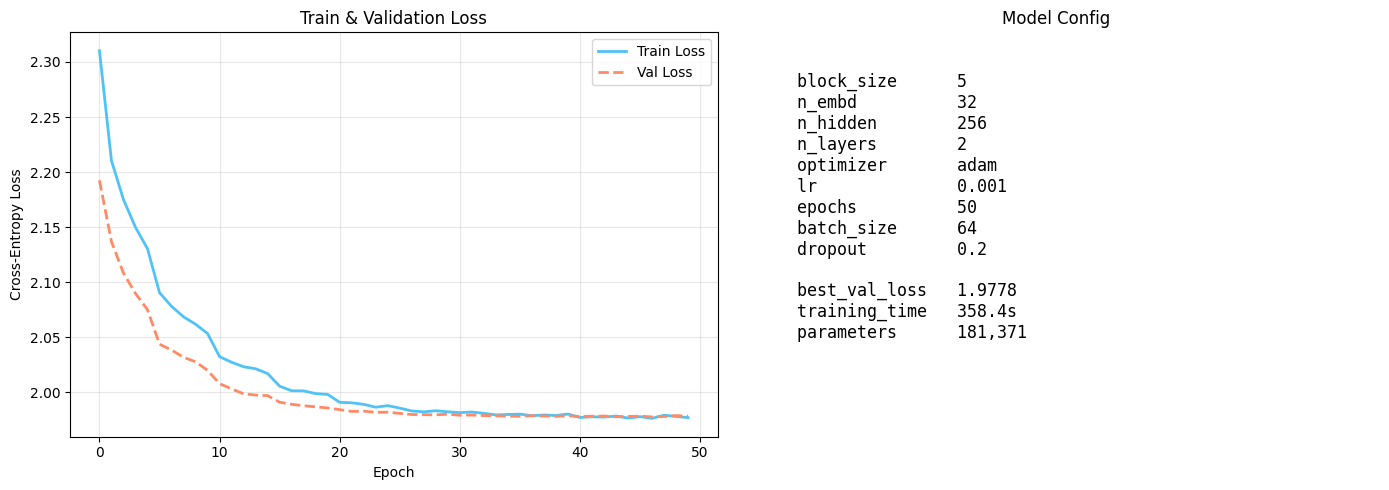

In [9]:
def plot_training(result, config):
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ── Left: train & val loss curves ─────────────────────
    axes[0].plot(result["train_losses"], label="Train Loss", color="#4fc3f7", lw=2)
    axes[0].plot(result["val_losses"],   label="Val Loss",   color="#ff8a65", lw=2, linestyle="--")
    axes[0].set_title("Train & Validation Loss")
    axes[0].set_xlabel("Epoch")
    axes[0].set_ylabel("Cross-Entropy Loss")
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # ── Right: config summary as text ─────────────────────
    axes[1].axis("off")
    lines = [f"{k:<15} {v}" for k, v in config.items()]
    lines += ["", f"{'best_val_loss':<15} {result['best_val_loss']:.4f}",
                  f"{'training_time':<15} {result['training_time']:.1f}s",
                  f"{'parameters':<15} {sum(p.numel() for p in model.parameters()):,}"]
    axes[1].text(0.1, 0.9, "\n".join(lines),
                 transform=axes[1].transAxes,
                 fontsize=12, verticalalignment="top",
                 fontfamily="monospace")
    axes[1].set_title("Model Config")

    plt.tight_layout()
    plt.savefig("saved_models/training_result.png", dpi=150)
    plt.show()

# ── Call it after training ─────────────────────────────────
plot_training(result, config)

## Load best model and console app

In [10]:
def load_best_model(save_dir="saved_models"):
    ckpt = torch.load(os.path.join(save_dir, "best_model.pt"),
                      map_location=device)
    cfg  = ckpt["config"]

    model = NameGenerator(
        vocab_size = vocab_size,
        n_embd     = cfg["n_embd"],
        block_size = cfg["block_size"],
        n_hidden   = cfg["n_hidden"],
        n_layers   = cfg["n_layers"],
        dropout    = cfg["dropout"]
    )
    model.load_state_dict(ckpt["model_state"])
    model.to(device)
    model.eval()

    print(f"Loaded best model  (val loss: {ckpt['val_loss']:.4f})")
    return model, cfg

In [ ]:
def save_model(model, config, result, path="saved_models/best_model.pt"):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    
    torch.save({
        "model_state":model.state_dict(),
        "config": config,
        "vocab":{
            "stoi": stoi,
            "itos": itos,
            "vocab_size": vocab_size
        },
        "result":{
            "best_val_loss":result["best_val_loss"],
            "train_losses": result["train_losses"],
            "val_losses": result["val_losses"],
        }
    }, path)
    size_mb=os.path.getsize(path)/1e6
    print(f"Saved->{path} ({size_mb:.2f} mb)")

In [11]:
def console_app():
    print("\n" + "="*50)
    print("  Name Generator — Console App")
    print("="*50)

    model, cfg = load_best_model()

    print("\nCommands:")
    print("  generate <n> <temp>   e.g.  generate 10 0.8")
    print("  compare <temp>        e.g.  compare 0.8")
    print("  info")
    print("  quit\n")

    while True:
        try:
            raw = input(">>> ").strip()
        except (EOFError, KeyboardInterrupt):
            print("\nGoodbye!")
            break

        if not raw:
            continue

        parts = raw.split()
        cmd   = parts[0].lower()

        if cmd == "quit":
            print("Goodbye!")
            break

        elif cmd == "info":
            print("\nModel config:")
            for k, v in cfg.items():
                print(f"  {k:<15} {v}")
            print(f"  {'device':<15} {device}")
            total = sum(p.numel() for p in model.parameters())
            print(f"  {'parameters':<15} {total:,}\n")

        elif cmd == "generate":
            n    = int(parts[1])   if len(parts) > 1 else 10
            temp = float(parts[2]) if len(parts) > 2 else 0.8
            names_out = model.generate(n=n, temperature=temp)
            print(f"\nGenerated {n} names (temp={temp}):")
            for i, name in enumerate(names_out, 1):
                print(f"  {i:2d}. {name.capitalize()}")
            print()

        elif cmd == "compare":
            temp_base = float(parts[1]) if len(parts) > 1 else 0.8
            configs   = [("conservative", temp_base * 0.5),
                         ("balanced",     temp_base),
                         ("creative",     min(temp_base * 1.5, 2.0))]
            print()
            for label, t in configs:
                names_out = model.generate(n=5, temperature=t)
                names_str = ",  ".join(n.capitalize() for n in names_out)
                print(f"  [{label:<13} temp={t:.2f}]  {names_str}")
            print()

        else:
            print(f"  Unknown command: '{cmd}'. Try: generate, compare, info, quit\n")

In [12]:
# ── Launch console app ────────────────────────────────────────────────
console_app()


  Name Generator — Console App
Loaded best model  (val loss: 1.9778)

Commands:
  generate <n> <temp>   e.g.  generate 10 0.8
  compare <temp>        e.g.  compare 0.8
  info
  quit


Generated 10 names (temp=0.8):
   1. Taylin
   2. Levie
   3. Sinna
   4. Krizta
   5. Marli
   6. Weliana
   7. Maziri
   8. Jaycea
   9. Jamese
  10. Jaberianna


  [conservative  temp=0.40]  Arian,  Cashawn,  Alexandrey,  Bristian,  Kamarion
  [balanced      temp=0.80]  Berbi,  Brie,  Semeco,  Nilly,  Khlon
  [creative      temp=1.20]  Jennan,  Mieon,  Amladah,  Maumodacp,  Natalajis


Model config:
  block_size      5
  n_embd          32
  n_hidden        256
  n_layers        2
  optimizer       adam
  lr              0.001
  epochs          50
  batch_size      64
  dropout         0.2
  device          cpu
  parameters      181,371

Goodbye!
